# Step 3: CLAP Embedding & Similarity Analysis on Processed Audio

Compare retrieval performance across five audio conditions:
- **original** — clean audio
- **highpass_1000Hz** — high-pass filtered at 1000 Hz
- **lowpass_4000Hz** — low-pass filtered at 4000 Hz
- **noisy_snr10dB** — white noise added at SNR = 10 dB
- **pitch_shift** — pitch shifted by -3 semitones

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import laion_clap

PROJECT_DIR = os.path.dirname(os.getcwd())
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
CSV_PATH    = os.path.join(DATA_DIR, 'metadata_500.csv')
os.makedirs(RESULTS_DIR, exist_ok=True)
EMBED_DIR   = os.path.join(RESULTS_DIR, 'embeddings')
FIGURES_DIR = os.path.join(RESULTS_DIR, 'figures')
METRICS_DIR = os.path.join(RESULTS_DIR, 'metrics')
os.makedirs(EMBED_DIR,   exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# audio conditions: label -> folder name
CONDITIONS = {
    'original':        'audio',
    'highpass_1000Hz': 'audio_highpass_1000Hz',
    'lowpass_4000Hz':  'audio_lowpass_4000Hz',
    'noisy_snr10dB':   'audio_noisy_snr10dB',
    'pitch_shift':     'audio_pitch_shift',
}

print('PROJECT_DIR:', PROJECT_DIR)
for label, folder in CONDITIONS.items():
    path = os.path.join(DATA_DIR, folder)
    print(f'  {label}: exists={os.path.isdir(path)}, files={len(os.listdir(path)) if os.path.isdir(path) else 0}')

/opt/anaconda3/envs/dl4m_audioText/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_DIR: /Users/liann77/One/NYUStudy/NYU26Spring/DL4M/finalGroupWorkClap
  original: exists=True, files=501
  highpass_1000Hz: exists=True, files=497
  lowpass_4000Hz: exists=True, files=497
  noisy_snr10dB: exists=True, files=497
  pitch_shift: exists=True, files=500


In [2]:
# filter out the 3 known bad files (empty audio, start_time beyond video duration)
BAD_FILES = {'34.wav', '196.wav', '247.wav'}

df = pd.read_csv(CSV_PATH)
clean_df = df[~df['audio_filename'].isin(BAD_FILES)].reset_index(drop=True)
captions = clean_df['caption'].tolist()

print(f'total samples: {len(df)}  ->  clean samples: {len(clean_df)}')
print(f'bad files skipped: {BAD_FILES}')

total samples: 500  ->  clean samples: 497
bad files skipped: {'196.wav', '34.wav', '247.wav'}


In [3]:
# load CLAP model
model = laion_clap.CLAP_Module(enable_fusion=False)
model.load_ckpt()
print('model loaded successfully!')

/opt/anaconda3/envs/dl4m_audioText/lib/python3.10/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729647065806/work/aten/src/ATen/native/TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 16412.31it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not o

Load our best checkpoint in the paper.
The checkpoint is already downloaded
Load Checkpoint...
logit_scale_a 	 Loaded
logit_scale_t 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_real.weight 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_imag.weight 	 Loaded
audio_branch.logmel_extractor.melW 	 Loaded
audio_branch.bn0.weight 	 Loaded
audio_branch.bn0.bias 	 Loaded
audio_branch.patch_embed.proj.weight 	 Loaded
audio_branch.patch_embed.proj.bias 	 Loaded
audio_branch.patch_embed.norm.weight 	 Loaded
audio_branch.patch_embed.norm.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm1.weight 	 Loaded
audio_branch.layers.0.blocks.0.norm1.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.relative_position_bias_table 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm2.we

In [4]:
# extract text embeddings (shared across all conditions)
print('extracting text embeddings...')
text_emb = model.get_text_embedding(captions, use_tensor=False)
text_norm = text_emb / np.linalg.norm(text_emb, axis=1, keepdims=True)
print('text embeddings shape:', text_emb.shape)

np.save(os.path.join(EMBED_DIR, 'text_embeddings.npy'), text_emb)

extracting text embeddings...
text embeddings shape: (497, 512)


In [5]:
# extract audio embeddings for each condition and save
audio_embs = {}

for label, folder in CONDITIONS.items():
    audio_dir = os.path.join(DATA_DIR, folder)
    paths = [
        os.path.join(audio_dir, row['audio_filename'])
        for _, row in clean_df.iterrows()
    ]
    print(f'\nextracting audio embeddings: {label} ...')
    emb = model.get_audio_embedding_from_filelist(x=paths, use_tensor=False)
    audio_embs[label] = emb
    np.save(os.path.join(EMBED_DIR, f'audio_emb_{label}.npy'), emb)
    print(f'  shape: {emb.shape}')

print('\nall audio embeddings extracted and saved!')


extracting audio embeddings: original ...
  shape: (497, 512)

extracting audio embeddings: highpass_1000Hz ...
  shape: (497, 512)

extracting audio embeddings: lowpass_4000Hz ...
  shape: (497, 512)

extracting audio embeddings: noisy_snr10dB ...
  shape: (497, 512)

extracting audio embeddings: pitch_shift ...
  shape: (497, 512)

all audio embeddings extracted and saved!


In [6]:
# compute retrieval metrics
def retrieval_metrics(sim_matrix):
    n = sim_matrix.shape[0]
    ranks = []
    for i in range(n):
        row = sim_matrix[i]
        rank = np.sum(row >= row[i]) - 1  # 0-indexed rank
        ranks.append(rank)
    ranks = np.array(ranks)
    return {
        'R@1':  float(np.mean(ranks < 1)),
        'R@5':  float(np.mean(ranks < 5)),
        'R@10': float(np.mean(ranks < 10)),
        'MedR': float(np.median(ranks) + 1),
    }

results = {}
sim_matrices = {}

for label, emb in audio_embs.items():
    audio_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    sim = audio_norm @ text_norm.T
    sim_matrices[label] = sim

    a2t = retrieval_metrics(sim)    # Audio -> Text
    t2a = retrieval_metrics(sim.T)  # Text -> Audio
    results[label] = {'A->T': a2t, 'T->A': t2a}

# print summary table
print(f'{"Condition":<20} {"Dir":<6} {"R@1":>6} {"R@5":>6} {"R@10":>7} {"MedR":>6}')
print('-' * 55)
for label, res in results.items():
    for direction, metrics in res.items():
        print(f'{label:<20} {direction:<6} {metrics["R@1"]:>6.4f} {metrics["R@5"]:>6.4f} {metrics["R@10"]:>7.4f} {metrics["MedR"]:>6.1f}')

Condition            Dir       R@1    R@5    R@10   MedR
-------------------------------------------------------
original             A->T   0.2636 0.6680  0.8028    3.0
original             T->A   0.2455 0.6901  0.8270    3.0
highpass_1000Hz      A->T   0.1710 0.4427  0.6056    7.0
highpass_1000Hz      T->A   0.1650 0.4950  0.6459    6.0
lowpass_4000Hz       A->T   0.2636 0.6499  0.7968    3.0
lowpass_4000Hz       T->A   0.2193 0.6600  0.8028    3.0
noisy_snr10dB        A->T   0.2193 0.5855  0.7284    4.0
noisy_snr10dB        T->A   0.2656 0.6217  0.7867    4.0
pitch_shift          A->T   0.1670 0.4447  0.5835    7.0
pitch_shift          T->A   0.1590 0.4688  0.6439    6.0


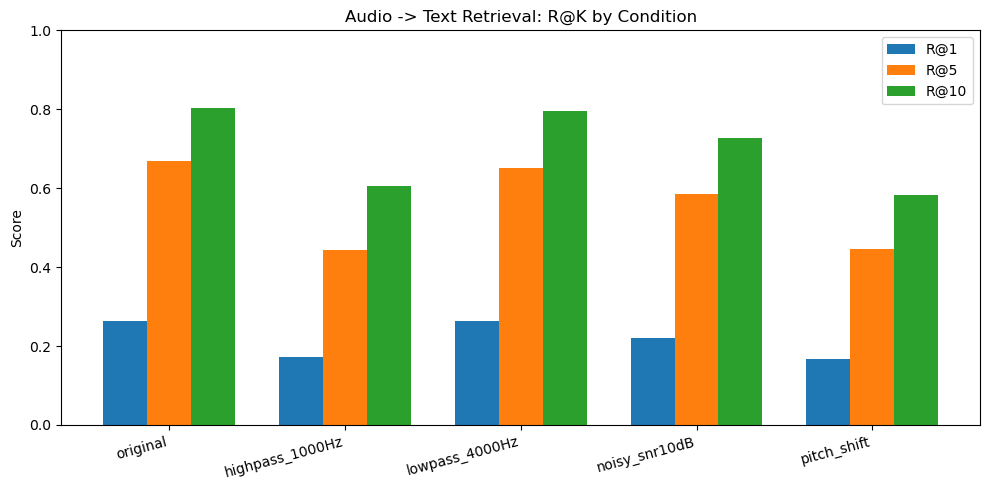

In [7]:
# visualization 1: bar chart comparing R@1, R@5, R@10 across conditions (Audio -> Text)
metrics_keys = ['R@1', 'R@5', 'R@10']
labels = list(results.keys())
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, metric in enumerate(metrics_keys):
    vals = [results[l]['A->T'][metric] for l in labels]
    ax.bar(x + i * width, vals, width, label=metric)

ax.set_xticks(x + width)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Audio -> Text Retrieval: R@K by Condition')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'retrieval_comparison_a2t.png'), dpi=150)
plt.show()

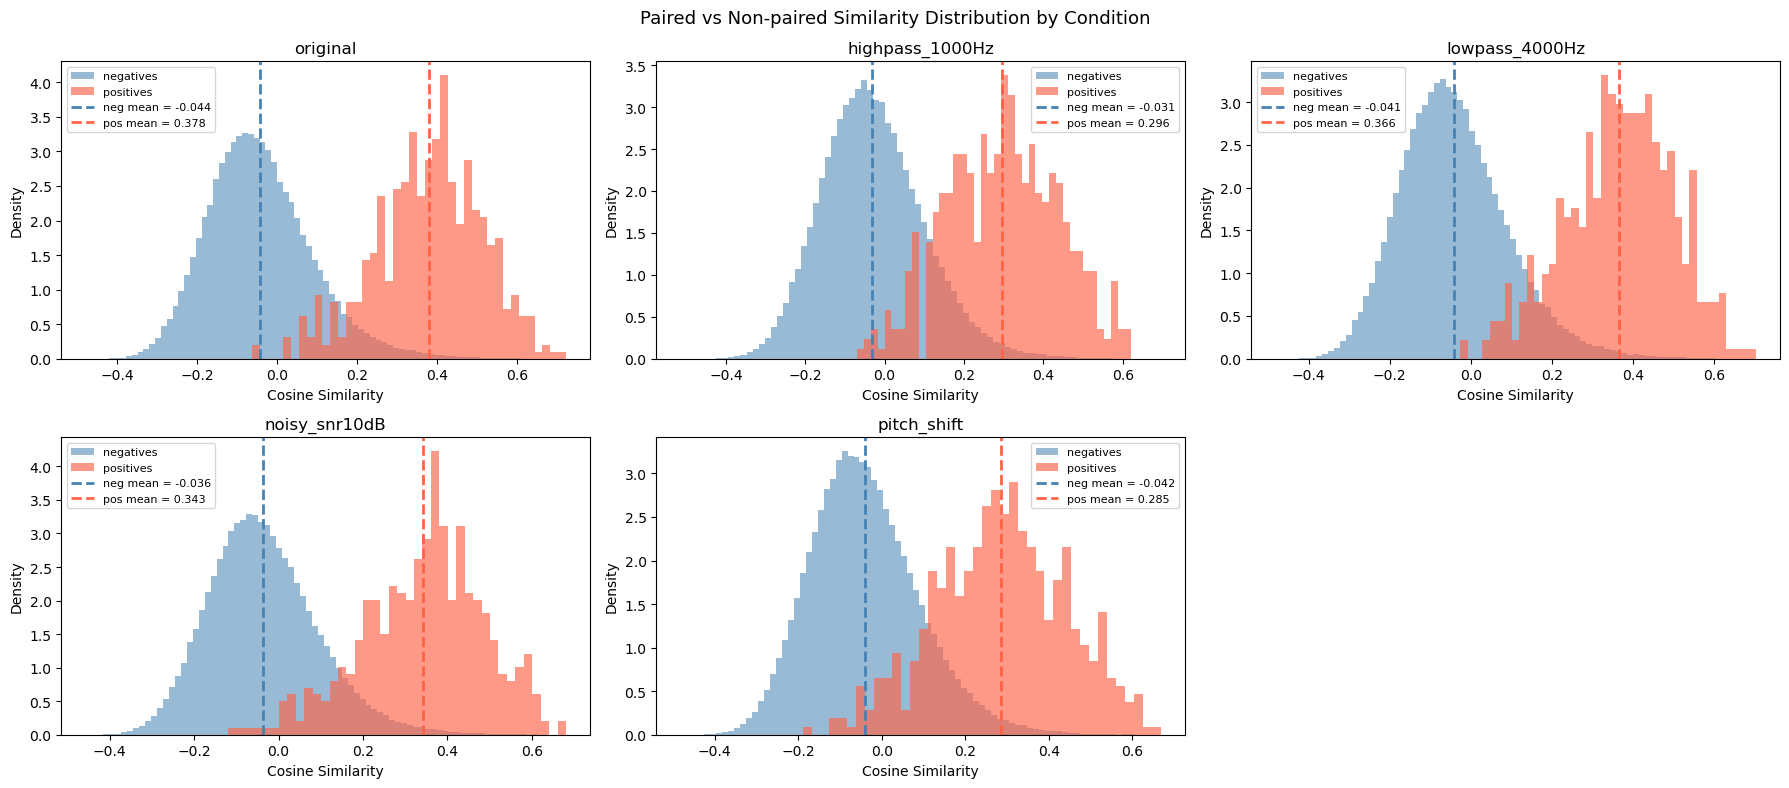

In [8]:
# visualization 2: paired similarity distribution for each condition (improved)

n_cond = len(sim_matrices)
ncols = 3
nrows = (n_cond + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for ax, (label, sim) in zip(axes, sim_matrices.items()):
    paired_sim = np.diag(sim)
    off_diag   = sim[~np.eye(sim.shape[0], dtype=bool)]

    # histogram (density)
    ax.hist(
        off_diag,
        bins=80,
        density=True,
        alpha=0.55,
        label='negatives',
        color='steelblue'
    )

    ax.hist(
        paired_sim,
        bins=40,
        density=True,
        alpha=0.65,
        label='positives',
        color='tomato'
    )

    # mean lines
    neg_mean = np.mean(off_diag)
    pos_mean = np.mean(paired_sim)

    ax.axvline(
        neg_mean,
        color='steelblue',
        linestyle='--',
        linewidth=2,
        label=f'neg mean = {neg_mean:.3f}'
    )

    ax.axvline(
        pos_mean,
        color='tomato',
        linestyle='--',
        linewidth=2,
        label=f'pos mean = {pos_mean:.3f}'
    )

    # labels
    ax.set_title(label)
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# hide unused axes
for ax in axes[n_cond:]:
    ax.set_visible(False)

plt.suptitle('Paired vs Non-paired Similarity Distribution by Condition', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'similarity_dist_by_condition_density.png'), dpi=150)
plt.show()

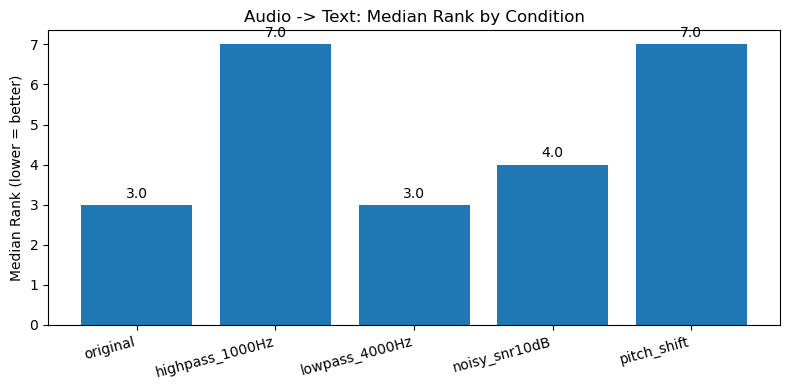

In [9]:
# visualization 3: MedR comparison A->T (lower is better)
fig, ax = plt.subplots(figsize=(8, 4))
medr_vals = [results[l]['A->T']['MedR'] for l in labels]
bars = ax.bar(labels, medr_vals)
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_ylabel('Median Rank (lower = better)')
ax.set_title('Audio -> Text: Median Rank by Condition')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'medr_comparison.png'), dpi=150)
plt.show()

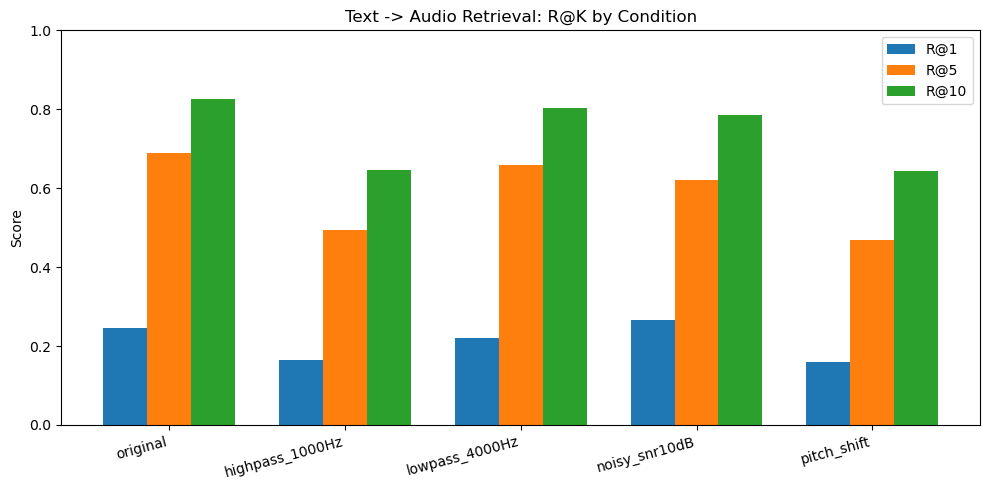

In [10]:
# visualization 4: T->A bar chart (R@1, R@5, R@10)
metrics_keys = ['R@1', 'R@5', 'R@10']
labels = list(results.keys())
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, metric in enumerate(metrics_keys):
    vals = [results[l]['T->A'][metric] for l in labels]
    ax.bar(x + i * width, vals, width, label=metric)

ax.set_xticks(x + width)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Text -> Audio Retrieval: R@K by Condition')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'retrieval_comparison_t2a.png'), dpi=150)
plt.show()

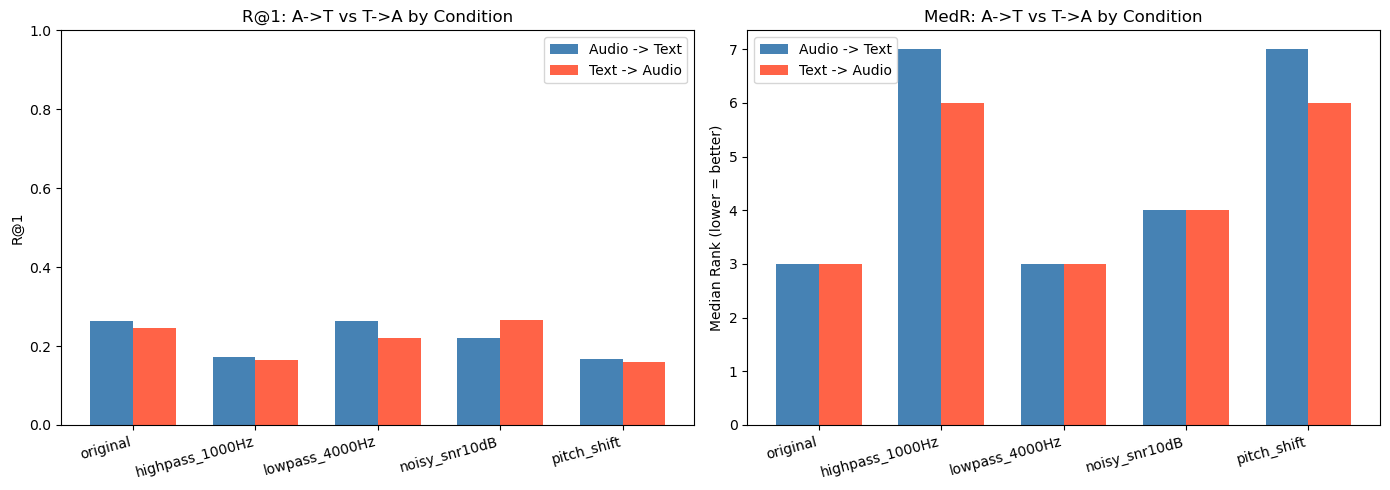

In [11]:
# visualization 5: A->T vs T->A side-by-side for R@1 and MedR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R@1 comparison
ax = axes[0]
x = np.arange(len(labels))
width = 0.35
a2t_r1 = [results[l]['A->T']['R@1'] for l in labels]
t2a_r1 = [results[l]['T->A']['R@1'] for l in labels]
ax.bar(x - width/2, a2t_r1, width, label='Audio -> Text', color='steelblue')
ax.bar(x + width/2, t2a_r1, width, label='Text -> Audio', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('R@1')
ax.set_title('R@1: A->T vs T->A by Condition')
ax.set_ylim(0, 1)
ax.legend()

# MedR comparison (lower is better)
ax = axes[1]
a2t_medr = [results[l]['A->T']['MedR'] for l in labels]
t2a_medr = [results[l]['T->A']['MedR'] for l in labels]
ax.bar(x - width/2, a2t_medr, width, label='Audio -> Text', color='steelblue')
ax.bar(x + width/2, t2a_medr, width, label='Text -> Audio', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Median Rank (lower = better)')
ax.set_title('MedR: A->T vs T->A by Condition')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'a2t_vs_t2a_comparison.png'), dpi=150)
plt.show()

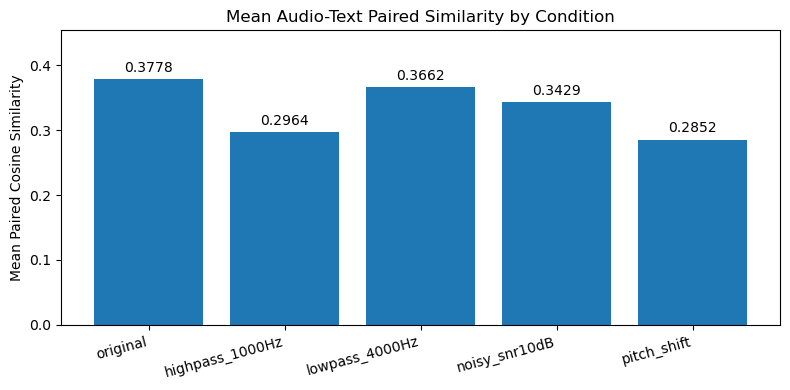

In [12]:
# visualization 6: mean paired similarity per condition
# (diagonal of sim_matrix = matched audio-text similarity)
fig, ax = plt.subplots(figsize=(8, 4))
mean_sims = [np.diag(sim_matrices[l]).mean() for l in labels]
bars = ax.bar(labels, mean_sims)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylabel('Mean Paired Cosine Similarity')
ax.set_title('Mean Audio-Text Paired Similarity by Condition')
ax.set_ylim(0, max(mean_sims) * 1.2)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'mean_paired_similarity.png'), dpi=150)
plt.show()

In [13]:
# save summary results to CSV
rows = []
for label, res in results.items():
    for direction, metrics in res.items():
        rows.append({'condition': label, 'direction': direction, **metrics})

summary_df = pd.DataFrame(rows)
summary_df.to_csv(os.path.join(METRICS_DIR, 'retrieval_summary.csv'), index=False)
print('saved to results/metrics/retrieval_summary.csv')
print(summary_df.to_string(index=False))

saved to results/retrieval_summary.csv
      condition direction      R@1      R@5     R@10  MedR
       original      A->T 0.263581 0.668008 0.802817   3.0
       original      T->A 0.245473 0.690141 0.826962   3.0
highpass_1000Hz      A->T 0.171026 0.442656 0.605634   7.0
highpass_1000Hz      T->A 0.164990 0.494970 0.645875   6.0
 lowpass_4000Hz      A->T 0.263581 0.649899 0.796781   3.0
 lowpass_4000Hz      T->A 0.219316 0.659960 0.802817   3.0
  noisy_snr10dB      A->T 0.219316 0.585513 0.728370   4.0
  noisy_snr10dB      T->A 0.265594 0.621730 0.786720   4.0
    pitch_shift      A->T 0.167002 0.444668 0.583501   7.0
    pitch_shift      T->A 0.158954 0.468813 0.643863   6.0
